<a href="https://colab.research.google.com/github/Ankitatiwary21/-PersonaGen/blob/main/Multi_Script_OCR_Pipeline_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
    print('VRAM    :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')
else:
    print('⚠️ No GPU — go to Runtime → Change runtime type → T4 GPU')

GPU available: True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
from google.colab import files
import os

print('Upload your kaggle.json ...')
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write(list(uploaded.values())[0].decode())
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

!pip install -q kaggle
print('✅ Kaggle API ready!')

Upload your kaggle.json ...


Saving kaggle (1).json to kaggle (1).json
✅ Kaggle API ready!


In [5]:
# ── Retry only the failed Latin datasets with longer timeout ──
import os, subprocess
from pathlib import Path

BASE_DIR = '/content/datasets'

FAILED_DATASETS = [
    ('ssarkar445/handwriting-recognitionocr', 'latin_ocr',   300),  # 5 minutes
    ('vaibhao/handwritten-characters',        'latin_chars', 300),  # 5 minutes
]

def download_dataset(slug, folder, timeout):
    dest = os.path.join(BASE_DIR, folder)
    os.makedirs(dest, exist_ok=True)
    cmd = f'kaggle datasets download -d {slug} -p {dest} --unzip -q'
    try:
        result = subprocess.run(cmd, shell=True, timeout=timeout, capture_output=True, text=True)
        if result.returncode == 0:
            n = sum(len(fs) for _, _, fs in os.walk(dest))
            print(f'   ✅ {n} files downloaded')
            return True
        else:
            print(f'   ❌ Failed: {result.stderr.strip()[:150]}')
            return False
    except subprocess.TimeoutExpired:
        print(f'   ⏱️ Still timed out after {timeout}s — try again later or skip')
        return False
    except Exception as e:
        print(f'   ❌ Error: {e}')
        return False

print('🔄 Retrying the 2 large Latin datasets...\n')
for slug, folder, timeout in FAILED_DATASETS:
    print(f'⏬ {slug} (timeout={timeout}s)')
    ok = download_dataset(slug, folder, timeout)

print('\n✅ Retry finished!')

🔄 Retrying the 2 large Latin datasets...

⏬ ssarkar445/handwriting-recognitionocr (timeout=300s)
   ✅ 413704 files downloaded
⏬ vaibhao/handwritten-characters (timeout=300s)
   ✅ 877721 files downloaded

✅ Retry finished!


In [6]:
import os, shutil, random
from pathlib import Path

UNIFIED_DIR = '/content/unified'
SCRIPTS     = ['Hindi', 'Bengali', 'Arabic', 'Latin']
VAL_SPLIT   = 0.15
random.seed(42)

# Clean slate
if os.path.exists(UNIFIED_DIR):
    shutil.rmtree(UNIFIED_DIR)
for split in ['train', 'val']:
    for script in SCRIPTS:
        os.makedirs(f'{UNIFIED_DIR}/{split}/{script}', exist_ok=True)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def copy_images(src_dir, script_name, tag='', max_images=None):
    if not os.path.exists(src_dir):
        print(f'    ⚠️  Source missing: {src_dir}')
        return {'train': 0, 'val': 0}
    all_imgs = [p for p in Path(src_dir).rglob('*') if p.suffix.lower() in IMG_EXTS and p.is_file()]
    if not all_imgs:
        print(f'    ⚠️  No images found in {src_dir}')
        return {'train': 0, 'val': 0}
    if max_images and len(all_imgs) > max_images:
        all_imgs = random.sample(all_imgs, max_images)
    random.shuffle(all_imgs)
    cut    = int(len(all_imgs) * (1 - VAL_SPLIT))
    splits = {'train': all_imgs[:cut], 'val': all_imgs[cut:]}
    counts = {'train': 0, 'val': 0}
    for split, imgs in splits.items():
        for i, img in enumerate(imgs):
            dst = f'{UNIFIED_DIR}/{split}/{script_name}/{tag}_{i:07d}{img.suffix}'
            try:
                shutil.copy2(img, dst)
                counts[split] += 1
            except Exception:
                pass
    return counts

print('Building unified dataset...\n')

# ── Hindi ──────────────────────────────────────────────────────────────────────
c = copy_images(f'{BASE_DIR}/hindi_devanagari', 'Hindi', 'dev', max_images=15000)
print(f'  Hindi (Devanagari): train={c["train"]}  val={c["val"]}')
c = copy_images(f'{BASE_DIR}/hindi_chars',      'Hindi', 'hch', max_images=8000)
print(f'  Hindi (chars)     : train={c["train"]}  val={c["val"]}')

# ── Bengali ────────────────────────────────────────────────────────────────────
c = copy_images(f'{BASE_DIR}/bengali_ekush', 'Bengali', 'eku', max_images=15000)
print(f'  Bengali (Ekush)   : train={c["train"]}  val={c["val"]}')
c = copy_images(f'{BASE_DIR}/bengali_bcrd',  'Bengali', 'brd', max_images=8000)
print(f'  Bengali (BCRD)    : train={c["train"]}  val={c["val"]}')

# ── Arabic ─────────────────────────────────────────────────────────────────────
c = copy_images(f'{BASE_DIR}/arabic_ahcd',    'Arabic', 'ahc', max_images=12000)
print(f'  Arabic (AHCD)     : train={c["train"]}  val={c["val"]}')
c = copy_images(f'{BASE_DIR}/arabic_letters', 'Arabic', 'arl', max_images=6000)
print(f'  Arabic (letters)  : train={c["train"]}  val={c["val"]}')

# ── Latin / English ────────────────────────────────────────────────────────────
c = copy_images(f'{BASE_DIR}/latin_ocr',   'Latin', 'loc')
print(f'  Latin (OCR)       : train={c["train"]}  val={c["val"]}')
c = copy_images(f'{BASE_DIR}/latin_chars', 'Latin', 'lch', max_images=10000)
print(f'  Latin (chars)     : train={c["train"]}  val={c["val"]}')

print('\n📊 Final unified counts:')
grand_total = 0
for split in ['train', 'val']:
    for script in SCRIPTS:
        n = len(list(Path(f'{UNIFIED_DIR}/{split}/{script}').glob('*')))
        grand_total += n
        flag = '⚠️ ' if n == 0 else '  '
        print(f'{flag}  {split:5s}/{script:10s}: {n:6d}')
print(f'\n  TOTAL: {grand_total} images')

if grand_total == 0:
    print('\n❌ No images at all — check Step 3')
elif grand_total < 1000:
    print('\n⚠️  Very few images. Re-run Step 3')
else:
    print('\n✅ Dataset ready — proceeding to training.')

Building unified dataset...

  Hindi (Devanagari): train=12750  val=2250
  Hindi (chars)     : train=6800  val=1200
    ⚠️  No images found in /content/datasets/bengali_ekush
  Bengali (Ekush)   : train=0  val=0
  Bengali (BCRD)    : train=6800  val=1200
  Arabic (AHCD)     : train=10200  val=1800
  Arabic (letters)  : train=5100  val=900
  Latin (OCR)       : train=351645  val=62056
  Latin (chars)     : train=8500  val=1500

📊 Final unified counts:
    train/Hindi     :  19550
    train/Bengali   :   6800
    train/Arabic    :  15300
    train/Latin     : 360145
    val  /Hindi     :   3450
    val  /Bengali   :   1200
    val  /Arabic    :   2700
    val  /Latin     :  63556

  TOTAL: 472701 images

✅ Dataset ready — proceeding to training.


In [7]:
import torch, timm, transformers
print(f'torch        : {torch.__version__}')
print(f'timm         : {timm.__version__}')
print(f'transformers : {transformers.__version__}')
print(f'Device       : {"cuda" if torch.cuda.is_available() else "cpu"}')

torch        : 2.10.0+cu128
timm         : 1.0.25
transformers : 5.0.0
Device       : cuda


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import timm
from tqdm import tqdm
import os
from pathlib import Path

# ── Settings ─────────────────────────────────────────────────────────────────────
DATA_DIR     = '/content/unified'
BATCH_SIZE   = 64
NUM_EPOCHS   = 5
LEARNING_RATE = 0.001
MODEL_NAME   = 'efficientnet_b0'
NUM_CLASSES  = 4
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Data transforms ─────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Datasets & Dataloaders ─────────────────────────────────────────────────────
train_dataset = ImageFolder(root=f'{DATA_DIR}/train', transform=train_transform)
val_dataset   = ImageFolder(root=f'{DATA_DIR}/val',   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Classes: {train_dataset.classes}')
print(f'Train images: {len(train_dataset):,} | Val images: {len(val_dataset):,}')

# ── Model ───────────────────────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ── Training Loop ───────────────────────────────────────────────────────────────
best_acc = 0.0
print(f'\n🚀 Starting training on {DEVICE} for {NUM_EPOCHS} epochs...\n')

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    val_acc   = 100. * val_correct / val_total

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.2f}%')

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), '/content/best_script_classifier.pth')
        print(f'   💾 Best model saved! (Val Acc = {val_acc:.2f}%)')

print('\n🎉 Training finished!')
print(f'Best validation accuracy: {best_acc:.2f}%')
print('Model saved as: /content/best_script_classifier.pth')

Classes: ['Arabic', 'Bengali', 'Hindi', 'Latin']
Train images: 401,795 | Val images: 70,906


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


🚀 Starting training on cuda for 5 epochs...



Epoch 1/5: 100%|██████████| 6279/6279 [33:04<00:00,  3.16it/s, loss=1.3225]


...

Epoch 3/5 | Train Loss: 0.0021 | Train Acc: 99.95% | Val Loss: 0.0011 | Val Acc: 99.97%


Epoch 4/5: 100%|██████████| 6279/6279 [33:06<00:00,  3.16it/s, loss=0.0000]


Epoch 4/5 | Train Loss: 0.0012 | Train Acc: 99.97% | Val Loss: 0.0010 | Val Acc: 99.98%


Epoch 5/5: 100%|██████████| 6279/6279 [33:04<00:00,  3.16it/s, loss=0.0001]


Epoch 5/5 | Train Loss: 0.0018 | Train Acc: 99.96% | Val Loss: 0.0246 | Val Acc: 99.39%

🎉 Training finished!
Best validation accuracy: 99.99%
Model saved as: /content/best_script_classifier.pth


✅ Model loaded! Upload any handwritten image(s) to test...



Saving Gemini_Generated_Image_rmun5mrmun5mrmun.png to Gemini_Generated_Image_rmun5mrmun5mrmun.png

🔍 Analysing: Gemini_Generated_Image_rmun5mrmun5mrmun.png
📌 Predicted Script : **Latin**
🎯 Confidence       : 99.97%


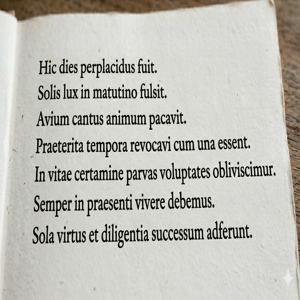

In [14]:
import torch
import timm
from torchvision import transforms
from PIL import Image
from google.colab import files
import torch.nn.functional as F

# Load the trained model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=4)
model.load_state_dict(torch.load('/content/best_script_classifier.pth', map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

CLASS_NAMES = ['Arabic', 'Bengali', 'Hindi', 'Latin']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('✅ Model loaded! Upload any handwritten image(s) to test...\n')

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'\n🔍 Analysing: {filename}')
    img = Image.open(filename).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)

        predicted_script = CLASS_NAMES[predicted_idx.item()]
        confidence_percent = confidence.item() * 100

    print(f'📌 Predicted Script : **{predicted_script}**')
    print(f'🎯 Confidence       : {confidence_percent:.2f}%')

    # Show the image
    display(img.resize((300, 300)))

In [15]:
!pip install -q easyocr googletrans==4.0.0-rc1
print("✅ Libraries installed! Now run the pipeline cell below.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages tha

✅ Full Multi-Script OCR + Translation Pipeline Ready (100% fixed!)
Upload your handwritten image now...



Saving ChatGPT Image Mar 26, 2026, 01_51_52 AM.png to ChatGPT Image Mar 26, 2026, 01_51_52 AM.png

🔍 Image: ChatGPT Image Mar 26, 2026, 01_51_52 AM.png
📌 Predicted Script : **Latin** (99.0%)
   Is this correct? Press Enter to accept, or type correct script (Arabic/Bengali/Hindi/Latin): bengali
   🔤 Loading OCR model for Latin...


Progress: |██████████████████████████████████████████████████| 100.0% Complete   🔤 Running OCR...
   📝 Raw Text: 96 -Fco JA O7 Ju< wx5 sforrI ZrCF ! G1G04 fct 01 4rTTTT 51796 7s114 (47 @Ri 34143 , TFBTTI, 44a 7 G14215 78467 @7 UGq `T4 wj54 Siariat GTGT5 RATA 4 47 &fza <aT 6T& TG T J #T G *rt TTGST T14, G1ITTA TTGT < Act Fg151 744 71 firia WI S1AT axfia ar5 & 7t, #67 <A 7 fg ai7& Tior 71I TG7T Jr146; C1AR Ota. FRR TT * FT A0tS G1 Gp5 #rG &i <1, TE, 34T {i5g (4ib [ib T3ragrr SrttM jAI GIAA {uqecT ? ?e a36 ftoqa TRAMT Ni TRICT, FrGT G1A Tpa
   ✅ Already in English: 96 -Fco JA O7 Ju< wx5 sforrI ZrCF ! G1G04 fct 01 4rTTTT 51796 7s114 (47 @Ri 34143 , TFBTTI, 44a 7 G14215 78467 @7 UGq `T4 wj54 Siariat GTGT5 RATA 4 47 &fza <aT 6T& TG T J #T G *rt TTGST T14, G1ITTA TTGT < Act Fg151 744 71 firia WI S1AT axfia ar5 & 7t, #67 <A 7 fg ai7& Tior 71I TG7T Jr146; C1AR Ota. FRR TT * FT A0tS G1 Gp5 #rG &i <1, TE, 34T {i5g (4ib [ib T3ragrr SrttM jAI GIAA {uqecT ? ?e a36 ftoqa TRAMT Ni TRICT, FrGT G1A Tpa


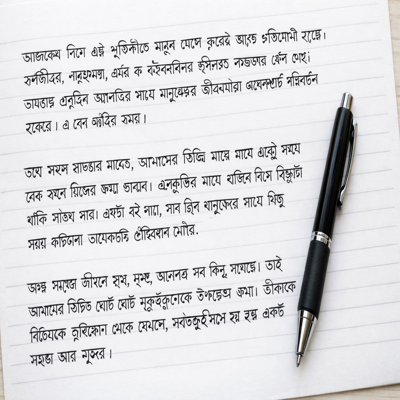

In [21]:
import torch
import timm
from torchvision import transforms
from PIL import Image
from google.colab import files
import torch.nn.functional as F
import easyocr
from deep_translator import GoogleTranslator

# ====================== 1. Load Script Classifier ======================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
script_model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=4)
script_model.load_state_dict(torch.load('/content/best_script_classifier.pth', map_location=DEVICE))
script_model = script_model.to(DEVICE)
script_model.eval()

CLASS_NAMES = ['Arabic', 'Bengali', 'Hindi', 'Latin']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✅ Full Multi-Script OCR + Translation Pipeline Ready (100% fixed!)")
print("Upload your handwritten image now...\n")

uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename).convert('RGB')

    # --- Step 1: Predict Script ---
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = script_model(input_tensor)
        prob = F.softmax(output[0], dim=0)
        confidence, idx = torch.max(prob, 0)
        predicted_script = CLASS_NAMES[idx.item()]
        conf_pct = confidence.item() * 100

    print(f"\n🔍 Image: {filename}")
    print(f"📌 Predicted Script : **{predicted_script}** ({conf_pct:.1f}%)")

    # --- Manual Override ---
    manual_script = input(f"   Is this correct? Press Enter to accept, or type correct script (Arabic/Bengali/Hindi/Latin): ").strip()
    if manual_script in CLASS_NAMES:
        predicted_script = manual_script
        print(f"   → Using manual override: **{predicted_script}**")

    # --- Step 2: Create OCR reader dynamically (this fixes all compatibility errors) ---
    lang_map = {
        'Latin':   ['en'],
        'Hindi':   ['en', 'hi'],
        'Bengali': ['en', 'bn'],
        'Arabic':  ['en', 'ar']
    }
    print(f"   🔤 Loading OCR model for {predicted_script}...")
    reader = easyocr.Reader(lang_map[predicted_script], gpu=True)

    # --- Step 3: OCR ---
    print(f"   🔤 Running OCR...")
    result = reader.readtext(filename, detail=0, paragraph=True)
    raw_text = " ".join(result).strip()
    print(f"   📝 Raw Text: {raw_text}")

    # --- Step 4: Translation to English ---
    if predicted_script != "Latin" and raw_text:
        print(f"   🌐 Translating to English...")
        try:
            src_lang = {'Arabic': 'ar', 'Bengali': 'bn', 'Hindi': 'hi'}[predicted_script]
            translation = GoogleTranslator(source=src_lang, target='en').translate(raw_text)
            print(f"   ✅ English Translation: {translation}")
        except Exception as e:
            print(f"   ⚠️ Translation failed: {e}")
    else:
        print(f"   ✅ Already in English: {raw_text}")

    # Show image
    display(img.resize((400, 400)))